![Logo del Instituto](https://raw.githubusercontent.com/Alelop-Itu/machine12026nocturno/refs/heads/main/img/logoitqv1.jpg)

# 01PAO26-26 - Variables cuantitativas

![Logo de Python](https://raw.githubusercontent.com/Alelop-Itu/machine12026nocturno/refs/heads/main/img/python_logo.png)

* Nombre: Alejandra López
* Fecha: **14-07-2026**
* Repositorio: [Link del repositorio de Github](https://github.com/Alelop-Itu/machine12026nocturno.git)

In [1]:
# Creación aleatoria de datos
import numpy as np
X = np.array([0.5, 23, 0.3, 4.5, 0.3, 0.5,
-28, -50, 60, -100, -10, -11, 13, 19, 1, 9])
print(X)

[   0.5   23.     0.3    4.5    0.3    0.5  -28.   -50.    60.  -100.
  -10.   -11.    13.    19.     1.     9. ]


In [8]:
# Medidas de tendencia central
from scipy import stats

media = np.mean(X)
mediana = np.median(X)
moda , _ = stats.mode(X)

print('media: ', media)
print('mediana: ', mediana)
print('moda :', moda)


media:  -4.24375
mediana:  0.5
moda : 0.3


In [3]:
# Medidas de posición
import numpy as np
import matplotlib.pyplot as plt

Q1 = np.percentile(X, 25)
Q3 = np.percentile(X, 75)
RIC = Q3 - Q1

lim_inf = Q1 - 1.5*RIC
lim_sup = Q3 + 1.5*RIC

print('RIC :', RIC)
print('limite inferior :', lim_inf)
print('limite superior :', lim_sup)

RIC : 20.25
limite inferior : -40.625
limite superior : 40.375


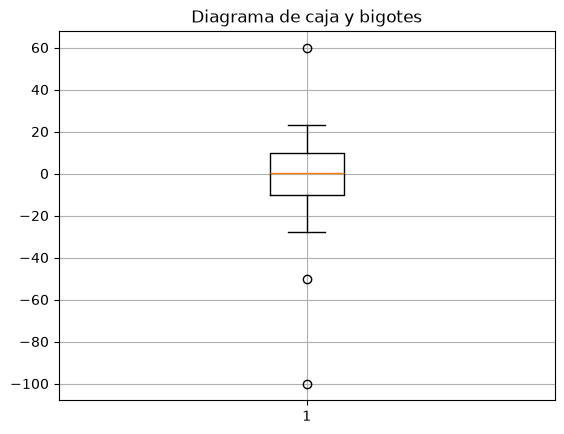

In [4]:
# Dibuja el diagrama de box and whiskers y determina visualmente el número de outliers
plt.boxplot(X)
plt.grid()
plt.title("Diagrama de caja y bigotes")
plt.show()


In [6]:
# Medidas de dispersión
desvest = np.std(X)

print('Desviación típica: ', desvest)
print('Varianza: ', desvest**2)

Desviación típica:  33.521242681880096
Varianza:  1123.6737109375


In [9]:
# Medidas de distribución
asimetria = stats.skew(X)
curtosis = stats.kurtosis(X, fisher=True) # https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kurtosis.html

print('Asimetría ', np.round(asimetria, 4))
print('Curtosis ', np.round(curtosis, 4))

if curtosis>0:
    print('Distribución Leptocúrtica')
elif curtosis<0:
    print('Distribución Platicúrtica')
else:
    print('Distribución Mesocúrtica')

Asimetría  -1.1302
Curtosis  2.2858
Distribución Leptocúrtica


In [11]:
# Cargar el set de datos de Iris
from sklearn import datasets
from pprint import pprint

iris = datasets.load_iris()

pprint(iris)
X = iris.data
y = iris.target



{'DESCR': '.. _iris_dataset:\n'
          '\n'
          'Iris plants dataset\n'
          '--------------------\n'
          '\n'
          '**Data Set Characteristics:**\n'
          '\n'
          ':Number of Instances: 150 (50 in each of three classes)\n'
          ':Number of Attributes: 4 numeric, predictive attributes and the '
          'class\n'
          ':Attribute Information:\n'
          '    - sepal length in cm\n'
          '    - sepal width in cm\n'
          '    - petal length in cm\n'
          '    - petal width in cm\n'
          '    - class:\n'
          '            - Iris-Setosa\n'
          '            - Iris-Versicolour\n'
          '            - Iris-Virginica\n'
          '\n'
          ':Summary Statistics:\n'
          '\n'
          '============== ==== ==== ======= ===== ====================\n'
          '                Min  Max   Mean    SD   Class Correlation\n'
          '============== ==== ==== ======= ===== ====================\n'
          '

**¿Qué tipo de asimetría se observa en la variable "longitud del pétalo"?**

La variable presenta una asimetría negativa (sesgo hacia la izquierda), con un valor de -0.2721.
    
**¿A qué tipo de distribución se ajusta la variable "ancho del sépalo", según su curtosis?**

La distribución es leptocúrtica, con un valor de curtosis de 0.1810.

### EJERCICIO EXTRA SOBRE EL DATASET DE IRIS
Extraer la media y la desviación típica de cada variable en función de la clase y representarlo en un gráfico (plt.errorbar)

In [14]:
import pandas as pd # Uso de dataframe
import matplotlib.pyplot as plt #Generar gráfico
from sklearn.datasets import load_iris #Cargar conjunto de datos de Iris

In [16]:
# Cargar datos
iris = load_iris() #Se carga el conjunto de la variable Iris
df = pd.DataFrame(iris.data, columns=iris.feature_names) # Se convierte números en dataset de pandas, asignando nombres a las columnas
df['class'] = iris.target_names[iris.target] #Se agrega una nueva columna "class" 

# Agrupar por clase y calcular estadísticos
stats = df.groupby('class').agg(['mean', 'std']) #Agrupa datos por la columna "class" y calcula la mediana y desviación estándar para todas las columnas del grupo

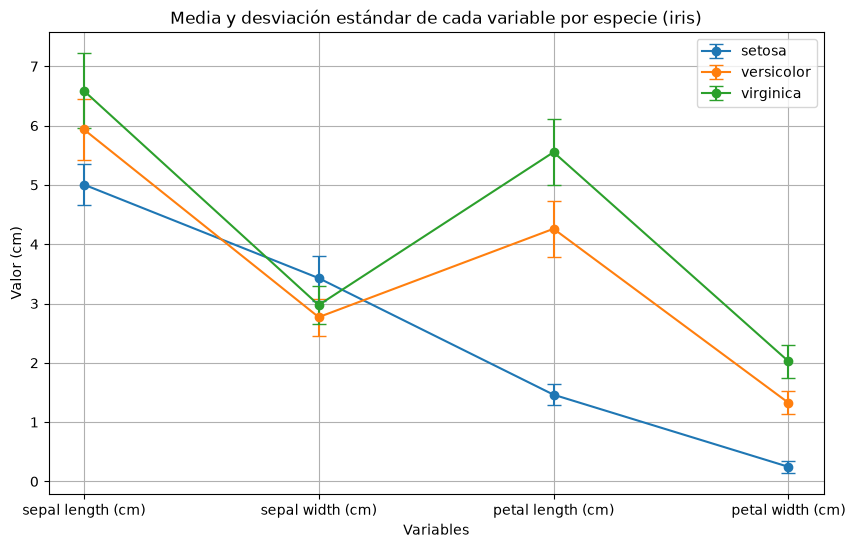

In [18]:
# Graficar
plt.figure(figsize=(10, 6)) #Da tamaño al área del gráfico
for species in df['class'].unique(): #Recorre cada especie de Iris
    means = stats.loc[species, (slice(None), 'mean')]  #Se extraen las medidas calculadas antes para la especie actual del bucle
    stds = stats.loc[species, (slice(None), 'std')]#Se entrae la des. est. calculada para la especie actual
    plt.errorbar(x=iris.feature_names, y=means, yerr=stds, label=species, capsize=5, marker='o')
    #x=iris.feature_names: Los nombres de las variables en el eje horizontal
    #y=means: Los valores medios en el eje vertical.
    #yerr=stds: Dibuja las barras de error usando la desviación estándar.
    #capsize=5: Añade una pequeña línea horizontal en los extremos de las barras de error.
    #marker='o': Coloca un punto en cada dato medio.
    #

plt.title("Media y desviación estándar de cada variable por especie (iris)") #Añade título y etiquetas a los ejes
plt.xlabel("Variables") #Añade título y etiquetas a los ejes
plt.ylabel("Valor (cm)")  #Añade título y etiquetas a los ejes
plt.legend()  # Crea la leyenda que identifica a qué color corresponde cada especie
plt.grid(True)  # Añade la cuadrícula de fondo
plt.show() 